# Ostrovok — Анализ маркетинговых каналов

**Данные:** 1.4M сессий, январь–июнь 2017  
**Задача:** структура трафика, качество каналов, путь пользователя, когортный retention, точки роста

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from itertools import combinations
from collections import Counter

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

DATA_PATH = '../data/Data for research.csv'

---
## 1. Sanity check + базовый контекст

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['session_datetime'])

# --- типы ---
df['session_with_booking'] = df['session_with_booking'].astype(bool)

print('Размер датасета:', df.shape)
print('Период:', df['session_datetime'].min().date(), '→', df['session_datetime'].max().date())
print()
df.dtypes

Размер датасета: (1427414, 9)
Период: 2017-01-01 → 2017-06-30



session_id                                     int64
user_id                                        int64
session_datetime           datetime64[ns, UTC+03:00]
device                                        object
marketing_channel_1                           object
marketing_channel_2                           object
session_with_booking                            bool
cancellation_prediction                      float64
commission_usd                               float64
dtype: object

In [3]:
# --- sanity checks ---
checks = {
    'Дубли session_id': df['session_id'].duplicated().sum() == 0,
    'Нет пропусков в ключевых полях': df[['user_id','device','marketing_channel_1','marketing_channel_2','session_with_booking']].isnull().sum().sum() == 0,
    'Период — 6 мес 2017': df['session_datetime'].dt.year.unique().tolist() == [2017],
    'Допустимые значения channel_1': set(df['marketing_channel_1'].unique()).issubset({'brand','cpc','metasearch','seo','partners'}),
    'Допустимые значения device': set(df['device'].unique()).issubset({'pc','mobile','tablet'}),
    'commission только у бронирований': (df.loc[~df['session_with_booking'], 'commission_usd'].isnull().all()),
    'commission > 0 у всех бронирований': (df.loc[df['session_with_booking'], 'commission_usd'] > 0).all(),
}

for name, result in checks.items():
    status = '✅' if result else '❌'
    print(f'{status} {name}')

✅ Дубли session_id
✅ Нет пропусков в ключевых полях
✅ Период — 6 мес 2017
✅ Допустимые значения channel_1
✅ Допустимые значения device
✅ commission только у бронирований
✅ commission > 0 у всех бронирований


In [4]:
# --- базовые KPI ---
bookings = df[df['session_with_booking']]

total_sessions   = len(df)
total_bookings   = df['session_with_booking'].sum()
overall_cr       = total_bookings / total_sessions * 100
gross_commission = bookings['commission_usd'].sum()
net_commission   = (bookings['commission_usd'] * (1 - bookings['cancellation_prediction'])).sum()
cancel_rate      = bookings['cancellation_prediction'].mean() * 100
unique_users     = df['user_id'].nunique()
multi_bookers    = bookings.groupby('user_id').size()
repeat_pct       = (multi_bookers > 1).sum() / multi_bookers.shape[0] * 100

print(f'Всего сессий:          {total_sessions:>12,}')
print(f'Уникальных пользов.:   {unique_users:>12,}')
print(f'Бронирований:          {total_bookings:>12,}')
print(f'CR (overall):          {overall_cr:>11.2f}%')
print(f'Gross commission:      ${gross_commission:>11,.0f}')
print(f'Net commission (exp.): ${net_commission:>11,.0f}')
print(f'Avg cancel rate:       {cancel_rate:>11.1f}%')
print(f'Повторные бронировщики:{repeat_pct:>10.1f}% (от тех, кто вообще бронировал)')

Всего сессий:             1,427,414
Уникальных пользов.:      1,229,387
Бронирований:                19,761
CR (overall):                 1.38%
Gross commission:      $    995,475
Net commission (exp.): $    495,341
Avg cancel rate:              50.3%
Повторные бронировщики:       9.7% (от тех, кто вообще бронировал)


> **Контекст:** датасет чистый, ~1.4M сессий за 6 месяцев. CR 1.38% — типичный уровень для travel OTA. Net commission ~$495K после корректировки на ожидаемые отмены.

---
## 2. Структура трафика

In [5]:
# --- по marketing_channel_1 ---
ch1 = df.groupby('marketing_channel_1').agg(
    sessions   = ('session_id', 'count'),
    bookings   = ('session_with_booking', 'sum'),
).assign(
    cr         = lambda x: x['bookings'] / x['sessions'] * 100,
    session_share = lambda x: x['sessions'] / x['sessions'].sum() * 100,
    booking_share = lambda x: x['bookings'] / x['bookings'].sum() * 100,
).sort_values('sessions', ascending=False)

display(ch1.round(2))

,sessions,bookings,cr,session_share,booking_share
marketing_channel_1,,,,,
cpc,574089,629,0.11,40.22,3.18
brand,545799,14778,2.71,38.24,74.78
metasearch,175058,3447,1.97,12.26,17.44
seo,78931,353,0.45,5.53,1.79
partners,53537,554,1.03,3.75,2.80


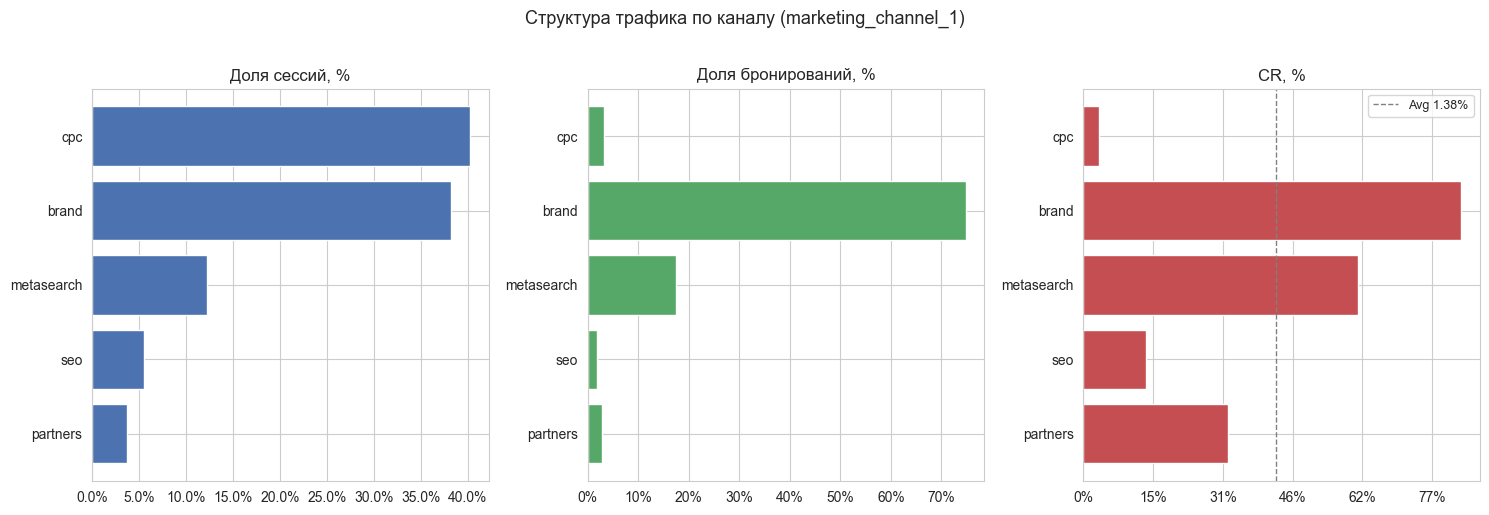

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ch1_sorted = ch1.sort_values('sessions', ascending=True)

axes[0].barh(ch1_sorted.index, ch1_sorted['session_share'], color='#4C72B0')
axes[0].set_title('Доля сессий, %')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

axes[1].barh(ch1_sorted.index, ch1_sorted['booking_share'], color='#55A868')
axes[1].set_title('Доля бронирований, %')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

axes[2].barh(ch1_sorted.index, ch1_sorted['cr'], color='#C44E52')
axes[2].set_title('CR, %')
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=ch1_sorted['cr'].max()*1.2))
axes[2].axvline(overall_cr, color='grey', linestyle='--', linewidth=1, label=f'Avg {overall_cr:.2f}%')
axes[2].legend(fontsize=9)

plt.suptitle('Структура трафика по каналу (marketing_channel_1)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

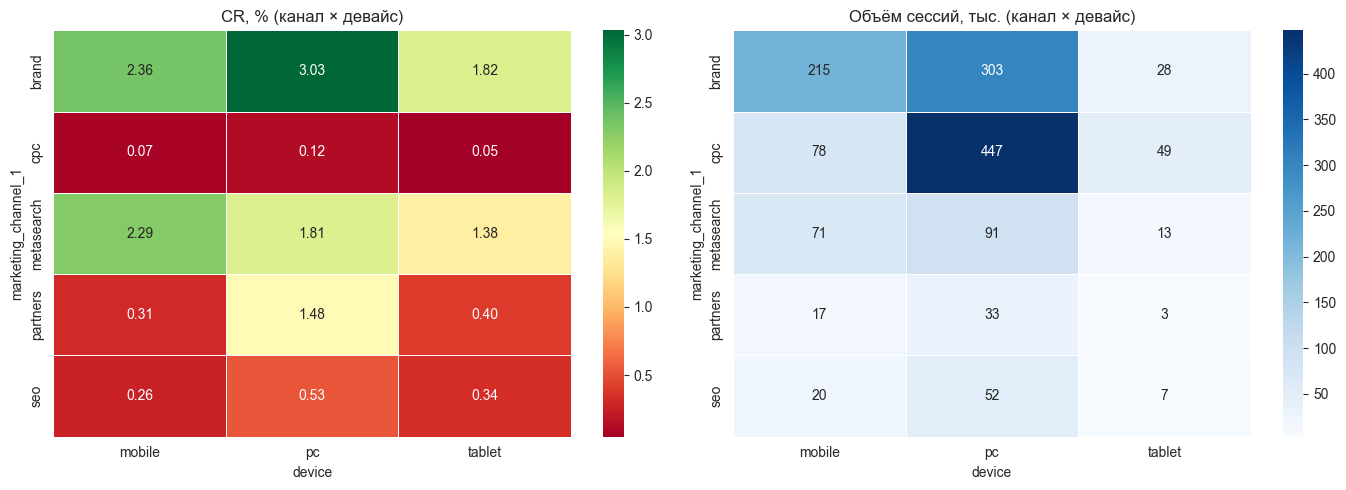

In [7]:
# --- heatmap канал x device ---
pivot_cr = df.pivot_table(
    index='marketing_channel_1',
    columns='device',
    values='session_with_booking',
    aggfunc='mean'
) * 100

pivot_vol = df.pivot_table(
    index='marketing_channel_1',
    columns='device',
    values='session_id',
    aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_cr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title('CR, % (канал × девайс)')

sns.heatmap(pivot_vol/1000, annot=True, fmt='.0f', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Объём сессий, тыс. (канал × девайс)')

plt.tight_layout()
plt.show()

In [8]:
# --- top sub-channels ---
ch2 = df.groupby(['marketing_channel_1','marketing_channel_2']).agg(
    sessions = ('session_id','count'),
    bookings = ('session_with_booking','sum'),
).assign(cr=lambda x: x['bookings']/x['sessions']*100).reset_index()
ch2 = ch2.sort_values(['marketing_channel_1','sessions'], ascending=[True,False])

print('Top sub-channels по объёму (топ-3 на канал):')
display(ch2.groupby('marketing_channel_1').head(3).reset_index(drop=True))

Top sub-channels по объёму (топ-3 на канал):


,marketing_channel_1,marketing_channel_2,sessions,bookings,cr
0,brand,type-in,360784,8253,2.29
1,brand,vital,110626,5150,4.66
2,brand,email,68343,1351,1.98
3,cpc,sem,571055,619,0.11
4,cpc,retargeting,3034,10,0.33
5,metasearch,trivago,94015,791,0.84
6,metasearch,hc,59894,1089,1.82
7,metasearch,gotravelunl,21108,1567,7.42
8,partners,cpa-affiliate,53537,554,1.03
9,seo,yandex,78931,353,0.45


> **Вывод:** ...

---
## 3. Качество трафика

In [9]:
# net commission per session (net RPS) и per booking
df['net_commission'] = df['commission_usd'] * (1 - df['cancellation_prediction'])

quality = df.groupby('marketing_channel_1').agg(
    sessions        = ('session_id','count'),
    bookings        = ('session_with_booking','sum'),
    gross_rev       = ('commission_usd','sum'),
    net_rev         = ('net_commission','sum'),
).assign(
    cr              = lambda x: x['bookings']/x['sessions']*100,
    gross_rps       = lambda x: x['gross_rev']/x['sessions'],
    net_rps         = lambda x: x['net_rev']/x['sessions'],
    net_per_booking = lambda x: x['net_rev']/x['bookings'],
    quality_score   = lambda x: x['cr'] * x['net_per_booking'],  # composite
).sort_values('quality_score', ascending=False)

display(quality[['sessions','bookings','cr','gross_rps','net_rps','net_per_booking','quality_score']].round(3))

,sessions,bookings,cr,gross_rps,net_rps,net_per_booking,quality_score
marketing_channel_1,,,,,,,
brand,545799,14778,2.71,1.37,0.68,25.23,68.31
metasearch,175058,3447,1.97,0.98,0.48,24.58,48.40
partners,53537,554,1.03,0.51,0.25,24.22,25.07
seo,78931,353,0.45,0.22,0.11,24.88,11.13
cpc,574089,629,0.11,0.06,0.03,24.79,2.72


In [10]:
# sub-channel quality — аномалии
avg_cr  = df['session_with_booking'].mean() * 100
avg_rps = df['net_commission'].sum() / len(df)

sub_quality = df.groupby(['marketing_channel_1','marketing_channel_2']).agg(
    sessions  = ('session_id','count'),
    net_rev   = ('net_commission','sum'),
    bookings  = ('session_with_booking','sum'),
).assign(
    cr  = lambda x: x['bookings']/x['sessions']*100,
    rps = lambda x: x['net_rev']/x['sessions'],
).reset_index()

# только значимые по объёму (>500 сессий)
sub_quality = sub_quality[sub_quality['sessions'] >= 500]

# флагируем аномалии
sub_quality['cr_flag']  = np.where(sub_quality['cr']  > avg_cr*2,  '🔼 high CR',
                          np.where(sub_quality['cr']  < avg_cr*0.3, '🔽 low CR', '—'))
sub_quality['rps_flag'] = np.where(sub_quality['rps'] > avg_rps*2,  '🔼 high RPS',
                          np.where(sub_quality['rps'] < avg_rps*0.3,'🔽 low RPS', '—'))

anomalies = sub_quality[(sub_quality['cr_flag'] != '—') | (sub_quality['rps_flag'] != '—')]
display(anomalies.sort_values('rps', ascending=False))

,marketing_channel_1,marketing_channel_2,sessions,net_rev,bookings,cr,rps,cr_flag,rps_flag
6,metasearch,gotravelunl,21108,39197.70,1567,7.42,1.86,🔼 high CR,🔼 high RPS
3,brand,vital,110626,129947.53,5150,4.66,1.17,🔼 high CR,🔼 high RPS
1,brand,smm,6046,410.89,24,0.40,0.07,🔽 low CR,🔽 low RPS
4,cpc,retargeting,3034,170.77,10,0.33,0.06,🔽 low CR,🔽 low RPS
5,cpc,sem,571055,15420.63,619,0.11,0.03,🔽 low CR,🔽 low RPS


> **Вывод:** ...

---
## 4. Динамика трафика

/var/folders/tk/n8qzt99n22b4jcxkj2dg44_40000gn/T/ipykernel_72523/2333966689.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['session_datetime'].dt.to_period('W').dt.start_time


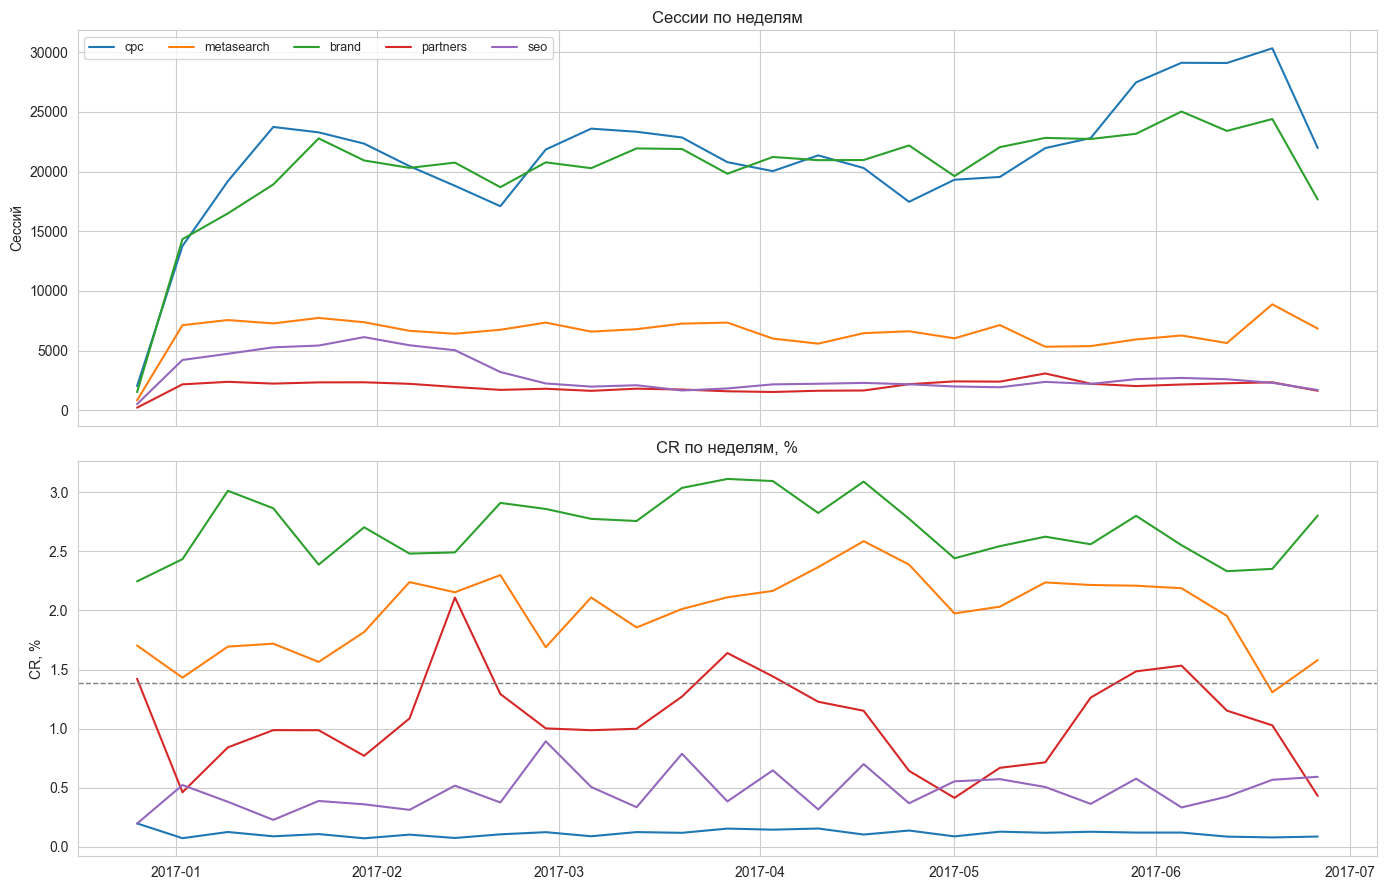

In [11]:
df['week'] = df['session_datetime'].dt.to_period('W').dt.start_time
df['hour'] = df['session_datetime'].dt.hour
df['dow']  = df['session_datetime'].dt.day_name()

weekly = df.groupby(['week','marketing_channel_1']).agg(
    sessions = ('session_id','count'),
    cr       = ('session_with_booking','mean'),
).reset_index()

channels = df['marketing_channel_1'].unique()
colors = sns.color_palette('tab10', len(channels))
color_map = dict(zip(channels, colors))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ch in channels:
    sub = weekly[weekly['marketing_channel_1'] == ch]
    axes[0].plot(sub['week'], sub['sessions'], label=ch, color=color_map[ch], linewidth=1.5)
    axes[1].plot(sub['week'], sub['cr']*100,   label=ch, color=color_map[ch], linewidth=1.5)

axes[0].set_title('Сессии по неделям')
axes[0].set_ylabel('Сессий')
axes[0].legend(ncol=5, fontsize=9)
axes[1].set_title('CR по неделям, %')
axes[1].set_ylabel('CR, %')
axes[1].axhline(overall_cr, color='grey', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

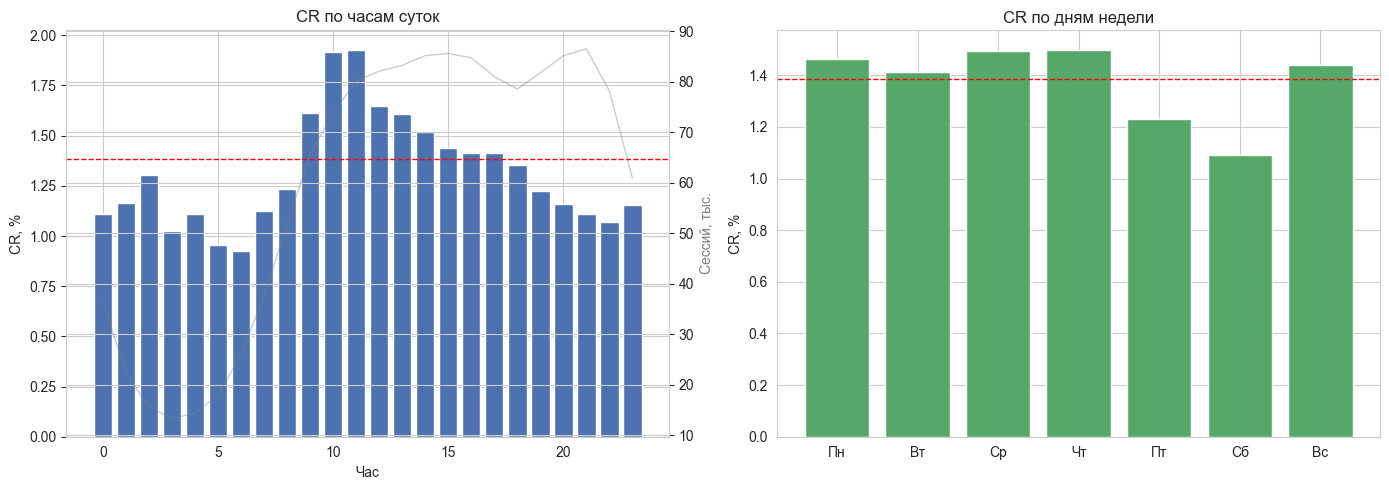

In [12]:
# сезонность по часу и дню недели
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df.groupby('hour')['session_with_booking'].agg(['mean','count'])
axes[0].bar(hourly.index, hourly['mean']*100, color='#4C72B0')
axes[0].axhline(overall_cr, color='red', linestyle='--', linewidth=1)
axes[0].set_title('CR по часам суток')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('CR, %')
ax02 = axes[0].twinx()
ax02.plot(hourly.index, hourly['count']/1000, color='grey', alpha=0.4, linewidth=1)
ax02.set_ylabel('Сессий, тыс.', color='grey')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('dow')['session_with_booking'].mean().reindex(dow_order) * 100
axes[1].bar(range(7), daily.values, color='#55A868')
axes[1].axhline(overall_cr, color='red', linestyle='--', linewidth=1)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])
axes[1].set_title('CR по дням недели')
axes[1].set_ylabel('CR, %')

plt.tight_layout()
plt.show()

> **Вывод:** ...

---
## 5. Путь пользователя к бронированию + атрибуция

In [13]:
# хронологическая история для конвертировавших пользователей
# берём путь до первого бронирования включительно

# пользователи, которые хотя бы раз забронировали
bookers = df[df['session_with_booking']]['user_id'].unique()
df_bookers = df[df['user_id'].isin(bookers)].copy()

# первое бронирование каждого
first_booking = (
    df_bookers[df_bookers['session_with_booking']]
    .sort_values('session_datetime')
    .groupby('user_id')['session_datetime']
    .first()
    .rename('first_booking_dt')
)

df_bookers = df_bookers.merge(first_booking, on='user_id')

# оставляем только сессии до первого бронирования включительно
df_path = df_bookers[df_bookers['session_datetime'] <= df_bookers['first_booking_dt']].copy()
df_path = df_path.sort_values(['user_id','session_datetime'])

# длина пути
path_length = df_path.groupby('user_id').size()

print('Медиана сессий до первого бронирования:', path_length.median())
print('Средняя:', path_length.mean().round(2))
print()
print('Распределение длины пути:')
print(path_length.value_counts().head(10).sort_index())

Медиана сессий до первого бронирования: 1.0
Средняя: 1.52

Распределение длины пути:
1     11705
2      2580
3       740
4       374
5       203
6       100
7        71
8        43
9        20
10       22
Name: count, dtype: int64


In [14]:
# топ цепочек (для путей длиной 1-4)
paths = (
    df_path.groupby('user_id')['marketing_channel_1']
    .apply(list)
    .reset_index(name='path')
)
paths['path_str'] = paths['path'].apply(lambda x: ' → '.join(x[:4]) + (' → ...' if len(x) > 4 else ''))
paths['path_len'] = paths['path'].apply(len)

top_paths = paths['path_str'].value_counts().head(20).reset_index()
top_paths.columns = ['path', 'users']
top_paths['share_pct'] = top_paths['users'] / len(paths) * 100
display(top_paths.head(15))

,path,users,share_pct
0,brand,8002,50.30
1,metasearch,2642,16.61
2,brand → brand,1799,11.31
3,cpc,548,3.44
4,brand → brand → brand,507,3.19
5,brand → brand → brand → brand → ...,364,2.29
6,metasearch → metasearch,354,2.23
7,partners,293,1.84
8,brand → brand → brand → brand,253,1.59
9,seo,220,1.38


In [15]:
# ===== АТРИБУЦИЯ =====
# Для каждого пользователя с первым бронированием строим 4 модели

booking_value = (
    df_path[df_path['session_with_booking']]
    .sort_values('session_datetime')
    .groupby('user_id')
    .first()[['net_commission']]
    .rename(columns={'net_commission':'booking_value'})
)

df_path2 = df_path.merge(booking_value, on='user_id')
df_path2['rank_asc']  = df_path2.groupby('user_id').cumcount() + 1   # от начала
df_path2['rank_desc'] = df_path2.groupby('user_id')['rank_asc'].transform('max') - df_path2['rank_asc'] + 1  # от конца
df_path2['path_len']  = df_path2.groupby('user_id')['rank_asc'].transform('max')

# ---- last paid: последний платный канал (не brand, не seo) ----
PAID = {'cpc','metasearch','partners'}
df_paid = df_path2[df_path2['marketing_channel_1'].isin(PAID)].copy()
last_paid = (
    df_paid.sort_values(['user_id','session_datetime'])
    .groupby('user_id')
    .last()[['marketing_channel_1','booking_value']]
)
attr_last_paid = last_paid.groupby('marketing_channel_1')['booking_value'].sum()

# Пользователи без платного касания → last-click на их канале
no_paid_users = set(booking_value.index) - set(last_paid.index)
df_no_paid = df_path2[df_path2['user_id'].isin(no_paid_users)].copy()
lc_no_paid = (
    df_no_paid.sort_values(['user_id','session_datetime'])
    .groupby('user_id')
    .last()[['marketing_channel_1','booking_value']]
).groupby('marketing_channel_1')['booking_value'].sum()
attr_last_paid = attr_last_paid.add(lc_no_paid, fill_value=0)

# ---- last-click ----
lc = (
    df_path2.sort_values(['user_id','session_datetime'])
    .groupby('user_id')
    .last()[['marketing_channel_1','booking_value']]
)
attr_last_click = lc.groupby('marketing_channel_1')['booking_value'].sum()

# ---- linear ----
df_path2['linear_credit'] = df_path2['booking_value'] / df_path2['path_len']
attr_linear = df_path2.groupby('marketing_channel_1')['linear_credit'].sum()

# ---- time decay (λ = 0.5 per step from end) ----
df_path2['td_weight']  = 0.5 ** (df_path2['rank_desc'] - 1)
df_path2['td_weight_norm'] = df_path2['td_weight'] / df_path2.groupby('user_id')['td_weight'].transform('sum')
df_path2['td_credit']  = df_path2['booking_value'] * df_path2['td_weight_norm']
attr_td = df_path2.groupby('marketing_channel_1')['td_credit'].sum()

# ---- сравнительная таблица ----
total_net = booking_value['booking_value'].sum()
attr = pd.DataFrame({
    'last_paid'  : attr_last_paid,
    'last_click' : attr_last_click,
    'linear'     : attr_linear,
    'time_decay' : attr_td,
}).fillna(0)

attr_pct = attr / attr.sum() * 100
attr_pct.columns = ['last_paid %','last_click %','linear %','time_decay %']
display(attr_pct.round(1))

,last_paid %,last_click %,linear %,time_decay %
marketing_channel_1,,,,
brand,69.30,71.10,71.00,71.00
cpc,4.50,3.90,4.00,4.00
metasearch,21.70,20.60,20.60,20.60
partners,2.70,2.50,2.40,2.40
seo,1.80,2.00,2.00,2.00


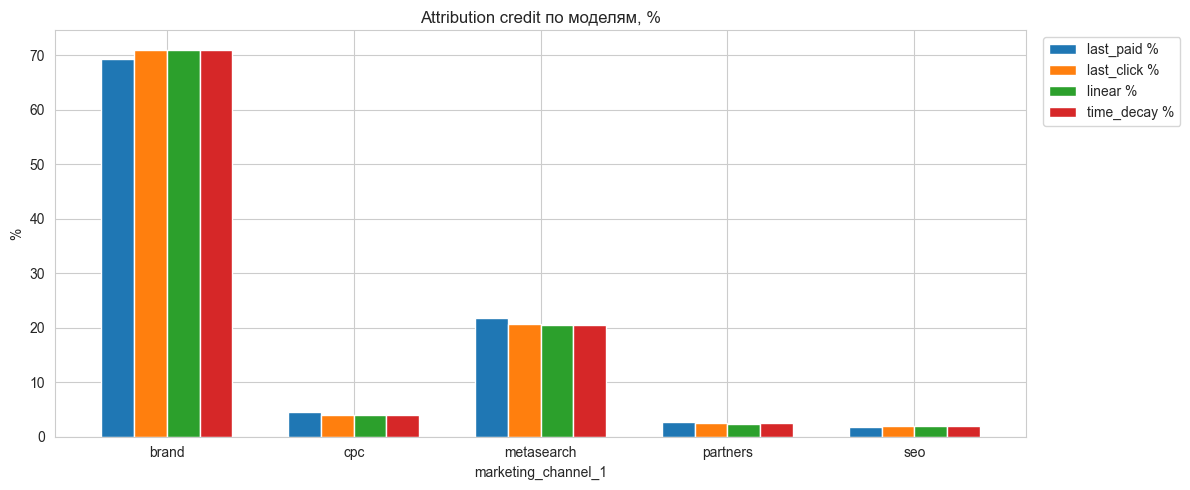


Delta last_paid vs linear (+ = переоценён в last_paid, - = недооценён):


marketing_channel_1
brand        -1.76
seo          -0.13
partners      0.32
cpc           0.42
metasearch    1.14
dtype: float64

In [16]:
# визуализация сравнения моделей
attr_pct.plot(kind='bar', figsize=(12, 5), width=0.7)
plt.title('Attribution credit по моделям, %')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# delta: last_paid vs linear (показывает кто недооценён/переоценён)
delta = attr_pct['last_paid %'] - attr_pct['linear %']
print('\nDelta last_paid vs linear (+ = переоценён в last_paid, - = недооценён):')
display(delta.sort_values())

In [17]:
# assisted conversions (канал в пути, но не последний)
last_touch = (
    df_path2.sort_values(['user_id','session_datetime'])
    .groupby('user_id')['marketing_channel_1']
    .last()
    .rename('last_channel')
)
df_path2 = df_path2.merge(last_touch, on='user_id')
df_path2['is_last'] = df_path2['marketing_channel_1'] == df_path2['last_channel']

assist = df_path2.groupby('marketing_channel_1').agg(
    total_touches = ('session_id','count'),
    last_touches  = ('is_last','sum'),
).assign(
    assisted      = lambda x: x['total_touches'] - x['last_touches'],
    assist_rate   = lambda x: x['assisted'] / x['total_touches'] * 100
)

print('Assisted conversions (% касаний, которые не последние):')
display(assist.sort_values('assist_rate', ascending=False))

Assisted conversions (% касаний, которые не последние):


,total_touches,last_touches,assisted,assist_rate
marketing_channel_1,,,,
seo,550,439,111,20.18
cpc,788,669,119,15.10
partners,604,518,86,14.24
metasearch,4465,4211,254,5.69
brand,17793,17296,497,2.79


> **Вывод:** ...

---
## 6. Когортный анализ и retention

In [18]:
# когорта = месяц первой сессии пользователя
first_session = (
    df.sort_values('session_datetime')
    .groupby('user_id')
    .agg(
        cohort_month    = ('session_datetime', lambda x: x.iloc[0].to_period('M')),
        first_channel   = ('marketing_channel_1', 'first'),
    )
)

df = df.merge(first_session, on='user_id')
df['activity_month'] = df['session_datetime'].dt.to_period('M')
df['months_since_cohort'] = (df['activity_month'] - df['cohort_month']).apply(lambda x: x.n)

/var/folders/tk/n8qzt99n22b4jcxkj2dg44_40000gn/T/ipykernel_72523/2685677990.py:6: UserWarning: Converting to Period representation will drop timezone information.
  cohort_month    = ('session_datetime', lambda x: x.iloc[0].to_period('M')),


/var/folders/tk/n8qzt99n22b4jcxkj2dg44_40000gn/T/ipykernel_72523/2685677990.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['activity_month'] = df['session_datetime'].dt.to_period('M')


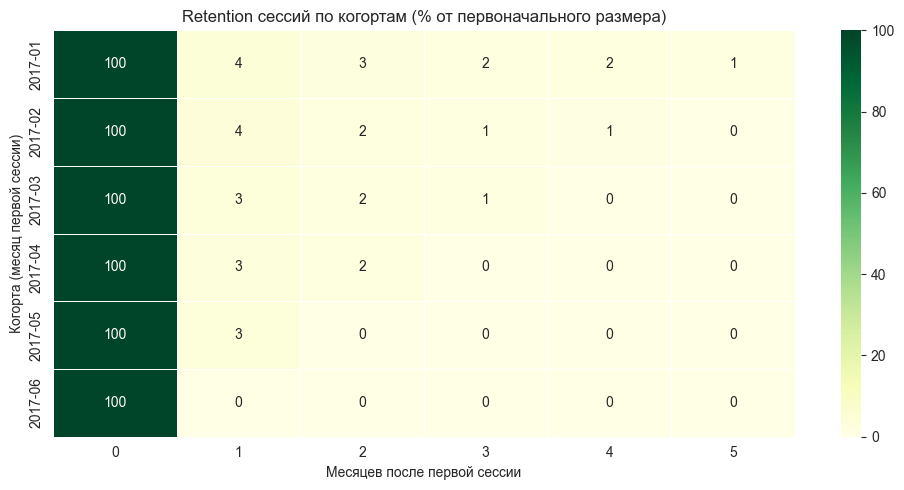

In [19]:
# retention по сессиям
cohort_size = first_session.groupby('cohort_month').size()

retention_sessions = (
    df.groupby(['cohort_month','months_since_cohort'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .div(cohort_size, axis=0)
    * 100
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    retention_sessions.iloc[:, :6],
    annot=True, fmt='.0f', cmap='YlGn',
    linewidths=0.5, vmin=0, vmax=100
)
plt.title('Retention сессий по когортам (% от первоначального размера)')
plt.xlabel('Месяцев после первой сессии')
plt.ylabel('Когорта (месяц первой сессии)')
plt.tight_layout()
plt.show()

In [20]:
# retention по бронированиям в разрезе канала привлечения
bookers_df = df[df['session_with_booking']].copy()

ch_cohort_size = (
    first_session[first_session.index.isin(bookers_df['user_id'].unique())]
    .groupby(['cohort_month','first_channel'])
    .size()
)

ch_retention = (
    bookers_df.groupby(['first_channel','months_since_cohort'])['user_id']
    .nunique()
    .reset_index()
)

# нормируем на размер когорты бронировщиков по каналу
bookers_by_channel = (
    first_session[first_session.index.isin(df[df['session_with_booking']]['user_id'].unique())]
    .groupby('first_channel')
    .size()
    .rename('cohort_size')
)

ch_ret = (
    bookers_df.groupby(['first_channel','months_since_cohort'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .div(bookers_by_channel, axis=0)
    * 100
)

print('Retention бронировщиков по каналу привлечения (% с повторным бронированием через N месяцев):')
display(ch_ret.iloc[:,:6].round(1))

Retention бронировщиков по каналу привлечения (% с повторным бронированием через N месяцев):


months_since_cohort,0,1,2,3,4,5
first_channel,,,,,,
brand,84.30,12.20,7.40,5.20,3.00,1.90
cpc,92.70,4.10,2.30,1.20,0.30,0.60
metasearch,93.70,3.90,2.20,1.20,0.60,0.20
partners,89.70,9.00,4.90,2.60,1.80,1.30
seo,86.20,6.60,6.00,3.10,3.40,1.60


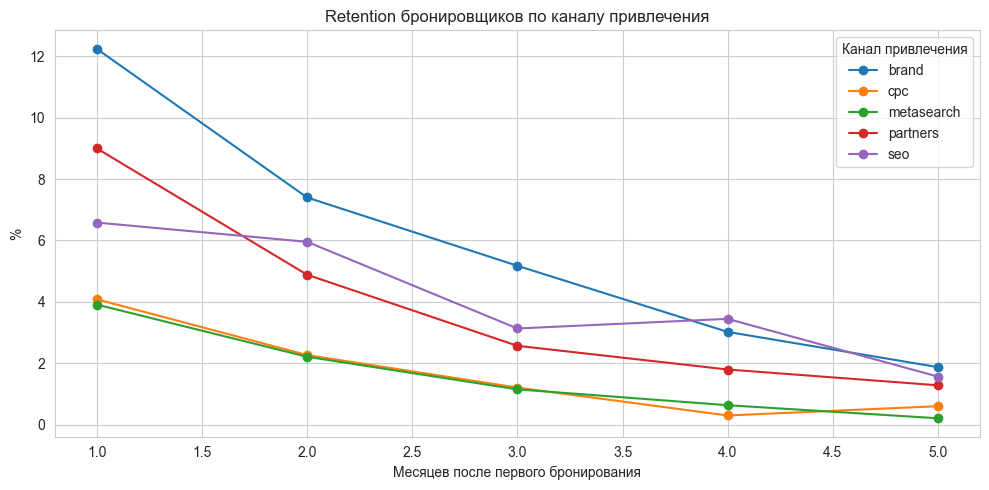

In [21]:
ch_ret.iloc[:,1:6].T.plot(figsize=(10,5), marker='o')
plt.title('Retention бронировщиков по каналу привлечения')
plt.xlabel('Месяцев после первого бронирования')
plt.ylabel('%')
plt.legend(title='Канал привлечения')
plt.tight_layout()
plt.show()

> **Вывод:** ...

---
## 7. Точки роста

In [22]:
# мобильный gap: CR mobile vs pc по каналам
mobile_gap = df.pivot_table(
    index='marketing_channel_1',
    columns='device',
    values='session_with_booking',
    aggfunc='mean'
) * 100
mobile_gap['mobile_vs_pc'] = mobile_gap.get('mobile',0) - mobile_gap.get('pc',0)
print('Mobile vs PC gap по CR (п.п.):')
display(mobile_gap[['pc','mobile','tablet','mobile_vs_pc']].round(2))

Mobile vs PC gap по CR (п.п.):


device,pc,mobile,tablet,mobile_vs_pc
marketing_channel_1,,,,
brand,3.03,2.36,1.82,-0.67
cpc,0.12,0.07,0.05,-0.05
metasearch,1.81,2.29,1.38,0.48
partners,1.48,0.31,0.40,-1.17
seo,0.53,0.26,0.34,-0.28


In [23]:
# top sub-channels: большой объём + низкий CR (потенциал оптимизации)
growth = sub_quality.copy()
growth['sessions_quartile'] = pd.qcut(growth['sessions'], q=4, labels=['Q1','Q2','Q3','Q4'])
growth['cr_vs_avg'] = growth['cr'] / avg_cr

# высокий объём + низкий CR = зона оптимизации
optimize_zone = growth[
    (growth['sessions_quartile'] == 'Q4') & (growth['cr_vs_avg'] < 0.7)
].sort_values('sessions', ascending=False)

print('Зона оптимизации: высокий объём + низкий CR:')
display(optimize_zone[['marketing_channel_1','marketing_channel_2','sessions','cr','rps']].head(10))

Зона оптимизации: высокий объём + низкий CR:


,marketing_channel_1,marketing_channel_2,sessions,cr,rps
5,cpc,sem,571055,0.11,0.03


In [24]:
# high CR sub-channels с малым объёмом = потенциал масштабирования
scale_zone = growth[
    (growth['sessions_quartile'].isin(['Q1','Q2'])) & (growth['cr_vs_avg'] > 1.5)
].sort_values('cr', ascending=False)

print('Зона масштабирования: высокий CR + малый объём:')
display(scale_zone[['marketing_channel_1','marketing_channel_2','sessions','cr','rps']].head(10))

Зона масштабирования: высокий CR + малый объём:


,marketing_channel_1,marketing_channel_2,sessions,cr,rps
6,metasearch,gotravelunl,21108,7.42,1.86


### Сводная таблица точек роста

| # | Проблема / возможность | Гипотеза причины | Рекомендуемое действие | Ожидаемый эффект |
|---|------------------------|------------------|------------------------|------------------|
| 1 | Mobile CR ниже PC во всех каналах | UX/checkout не адаптирован под мобайл | UX-аудит мобильного флоу, A/B тест упрощённого checkout | +X% CR mobile |
| 2 | ... | ... | ... | ... |
| 3 | ... | ... | ... | ... |
| 4 | ... | ... | ... | ... |
| 5 | ... | ... | ... | ... |

> *Таблица заполняется по результатам расчётов выше*